# 🏡 House Price Prediction using Machine Learning

### Internship Project – Week 1

**Name:** Charan Teja Arangi

**Project:** House Price Prediction

**Tools Used**

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Problem Statement

The objective of this project is to predict house prices using property features such as area, number of bedrooms, bathrooms, stories, parking, furnishing status, and other characteristics.

The project involves data preprocessing, exploratory data analysis, model development, evaluation, visualization, and business insights using machine learning techniques.

## Objectives

- Understand the housing dataset.
- Perform data cleaning and preprocessing.
- Explore relationships between house features and price.
- Build Linear Regression and Random Forest models.
- Compare model performance using MAE, RMSE, and R².
- Identify the most influential features affecting house prices.

In [1]:
# ======================================================
# Import Required Libraries
# ======================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ======================================================
# Load Dataset
# ======================================================

df = pd.read_csv("Housing.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Preview the dataset
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of understanding the dataset before building machine learning models. It helps identify data quality issues, understand feature distributions, detect relationships between variables, and make informed preprocessing decisions.

## 1. Preview the Dataset

Display the first 10 rows to understand the structure of the dataset.

In [4]:
# Display first 10 rows

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 2. Dataset Shape

The shape tells us how many observations (rows) and features (columns) are present.

In [5]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 545
Number of Columns : 13


## 3. Feature Names

In [6]:
print("Dataset Columns:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Dataset Columns:

1. price
2. area
3. bedrooms
4. bathrooms
5. stories
6. mainroad
7. guestroom
8. basement
9. hotwaterheating
10. airconditioning
11. parking
12. prefarea
13. furnishingstatus


## 4. Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


## 5. Statistical Summary

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


## 6. Missing Values Analysis

In [9]:
missing = df.isnull().sum()

missing

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [10]:
missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_table

,Missing Values,Percentage
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


## 7. Duplicate Records

In [11]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## 8. Unique Values

In [12]:
unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique

,Unique Values
price,219
area,284
bedrooms,6
bathrooms,4
stories,4
mainroad,2
guestroom,2
basement,2
hotwaterheating,2
airconditioning,2


In [13]:
datatype = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

datatype

,Column,Data Type
0,price,int64
1,area,int64
2,bedrooms,int64
3,bathrooms,int64
4,stories,int64
5,mainroad,object
6,guestroom,object
7,basement,object
8,hotwaterheating,object
9,airconditioning,object


## 9. Target Variable

In [14]:
target = "price"

print("Target Variable :", target)

Target Variable : price


In [15]:
numerical_columns = df.select_dtypes(include=np.number).columns

categorical_columns = df.select_dtypes(exclude=np.number).columns

In [16]:
print("Numerical Features")

print(numerical_columns)

Numerical Features
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


In [17]:
print("Categorical Features")

print(categorical_columns)

Categorical Features
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


## EDA Summary

- Dataset contains 545 rows and 13 columns.
- Target variable is **price**.
- Numerical features include area, bedrooms, bathrooms, etc.
- Categorical features include furnishing status, main road, air conditioning, etc.
- Missing values will be handled in the preprocessing stage.
- Duplicate rows will be removed before model training.

# Data Preprocessing & Cleaning

Data preprocessing is one of the most important stages of a Machine Learning pipeline. In this phase, we clean the dataset by handling missing values, removing duplicate records, converting categorical variables into numerical format, and preparing the data for model training.

In [19]:
# =====================================================
# Create a Backup Copy
# =====================================================

df_clean = df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [20]:
# =====================================================
# Missing Values
# =====================================================

missing = pd.DataFrame({
    "Missing Values": df_clean.isnull().sum(),
    "Percentage": (df_clean.isnull().sum()/len(df_clean))*100
})

missing

,Missing Values,Percentage
price,0,0.0
area,0,0.0
bedrooms,0,0.0
bathrooms,0,0.0
stories,0,0.0
mainroad,0,0.0
guestroom,0,0.0
basement,0,0.0
hotwaterheating,0,0.0
airconditioning,0,0.0


In [21]:
num_cols = df_clean.select_dtypes(include=np.number).columns

cat_cols = df_clean.select_dtypes(exclude=np.number).columns

In [22]:
df_clean[num_cols] = df_clean[num_cols].fillna(
    df_clean[num_cols].median()
)

In [23]:
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(
        df_clean[col].mode()[0]
    )

In [24]:
df_clean.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [25]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [26]:
categorical_columns = df_clean.select_dtypes(
    include='object'
).columns

print(categorical_columns)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [27]:
for col in categorical_columns:

    print("="*40)

    print(col)

    print(df_clean[col].value_counts())

    print("="*40)

mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64
prefarea
prefarea
no     417
yes    128
Name: count, dtype: int64
furnishingstatus
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


In [28]:
df_clean = pd.get_dummies(
    df_clean,
    drop_first=True,
    dtype=int
)

In [29]:
df_clean.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [30]:
datatype = pd.DataFrame({

    "Column": df_clean.columns,

    "Data Type": df_clean.dtypes.values

})

datatype

,Column,Data Type
0,price,int64
1,area,int64
2,bedrooms,int64
3,bathrooms,int64
4,stories,int64
5,parking,int64
6,mainroad_yes,int64
7,guestroom_yes,int64
8,basement_yes,int64
9,hotwaterheating_yes,int64


In [31]:
X = df_clean.drop("price", axis=1)

y = df_clean["price"]

In [32]:
print("Features Shape :", X.shape)

print("Target Shape :", y.shape)

Features Shape : (545, 13)
Target Shape : (545,)


In [33]:
df_clean.to_csv(
    "cleaned_housing.csv",
    index=False
)

# Data Visualization

Data visualization helps understand the distribution of variables, identify relationships between features, detect outliers, and support feature selection before building machine learning models.

In [34]:
# ======================================================
# Plot Settings
# ======================================================

plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid",
    palette="viridis"
)

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## Distribution of House Prices

This histogram shows how house prices are distributed in the dataset.

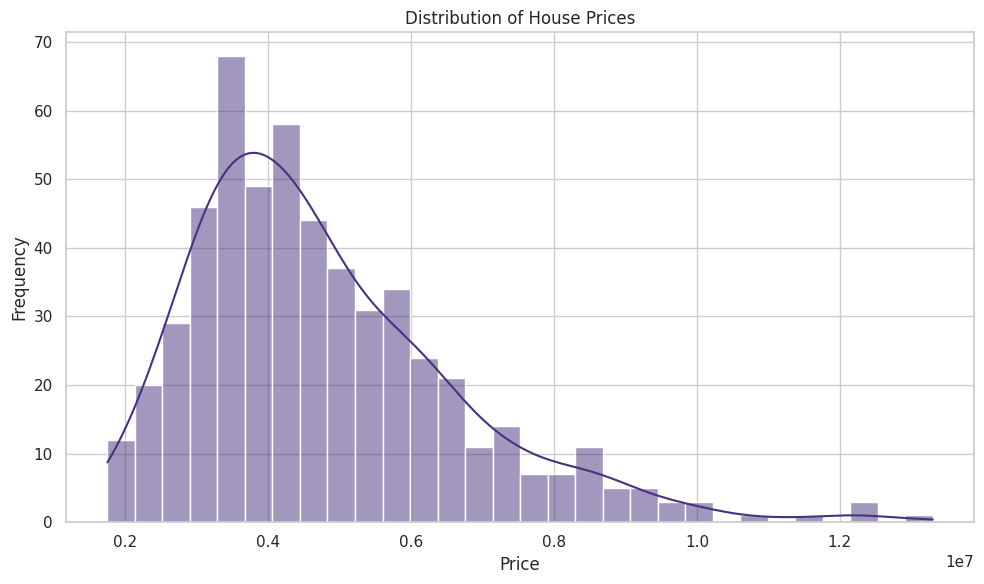

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_clean,
    x="price",
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("histogram.png",dpi=300)

plt.show()

### Observation

- Most houses fall within the middle price range.
- Few houses are extremely expensive.
- The distribution appears slightly right-skewed.

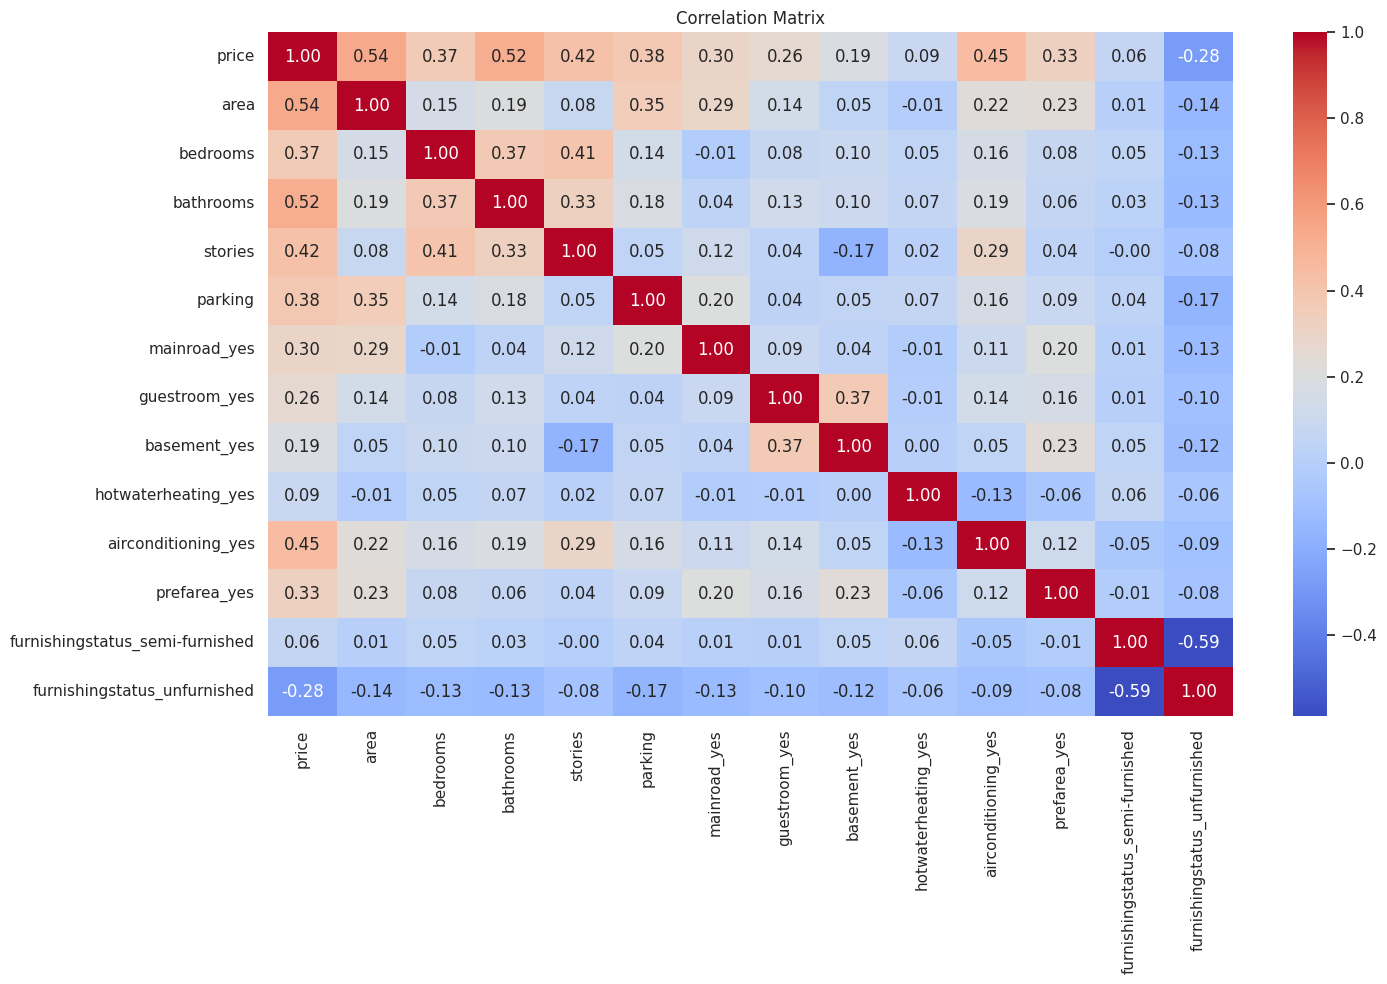

In [36]:
plt.figure(figsize=(15,10))

corr = df_clean.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig("heatmap.png",dpi=300)

plt.show()

### Observation

Features having correlation values closer to 1 have a strong positive relationship with house price.

Features closer to -1 have a strong negative relationship.

Features around 0 have little influence.

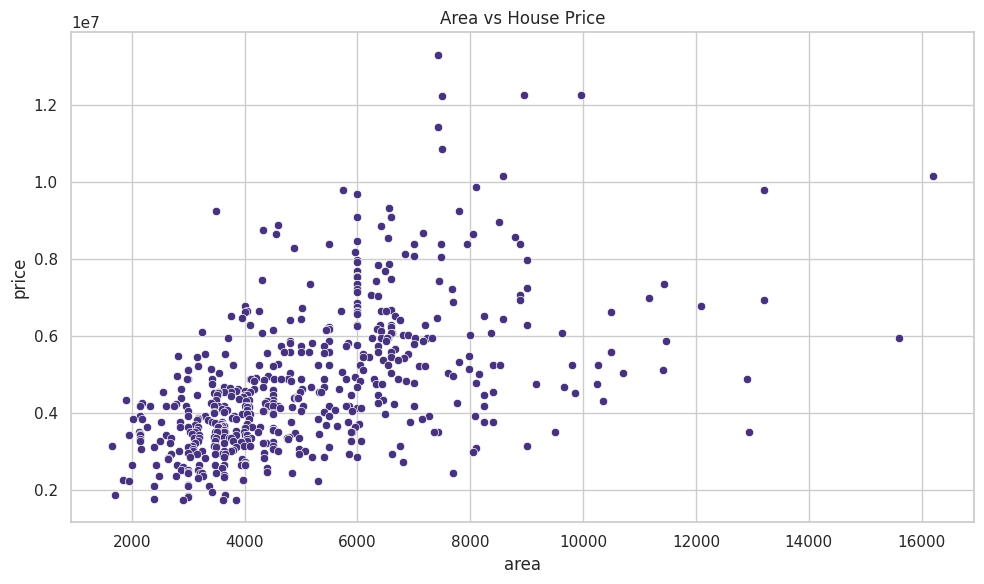

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="area",
    y="price"
)

plt.title("Area vs House Price")

plt.tight_layout()

plt.savefig("area_vs_price.png",dpi=300)

plt.show()

Larger houses generally have higher prices.

Area appears positively correlated with price.

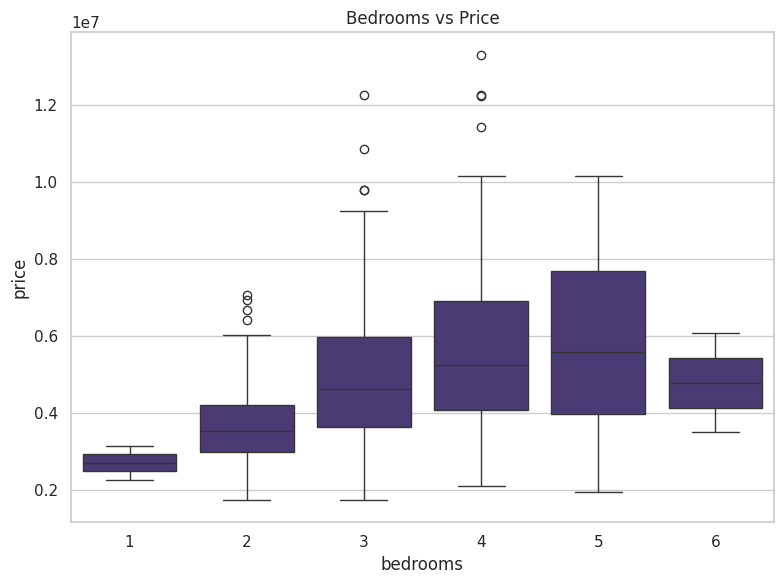

In [38]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price"
)

plt.title("Bedrooms vs Price")

plt.tight_layout()

plt.show()

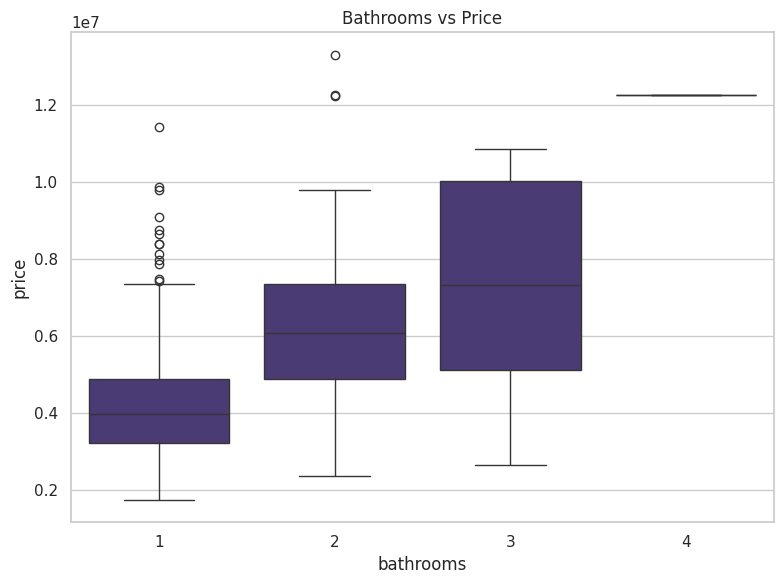

In [39]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="bathrooms",
    y="price"
)

plt.title("Bathrooms vs Price")

plt.tight_layout()

plt.show()

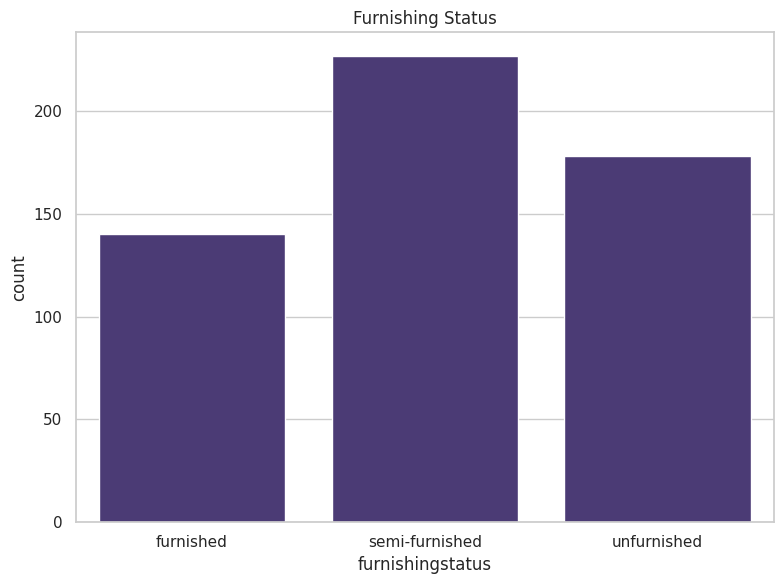

In [40]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x="furnishingstatus"
)

plt.title("Furnishing Status")

plt.tight_layout()

plt.show()

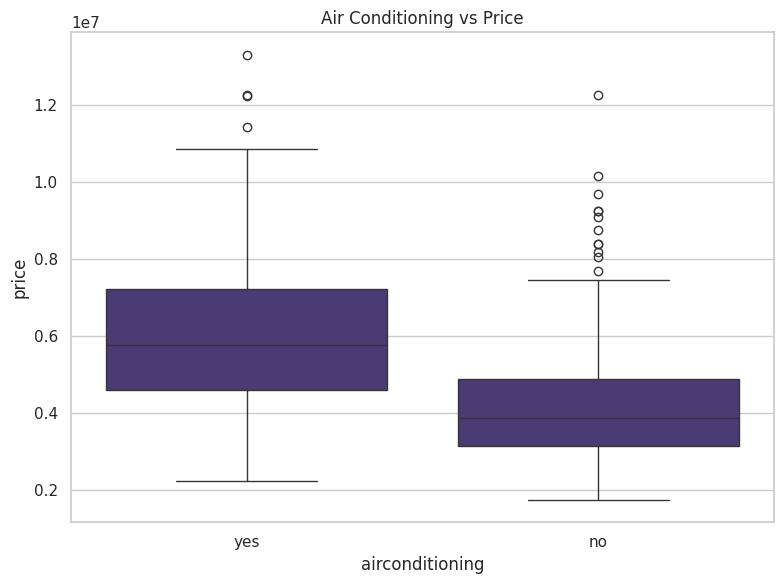

In [41]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="airconditioning",
    y="price"
)

plt.title("Air Conditioning vs Price")

plt.tight_layout()

plt.show()

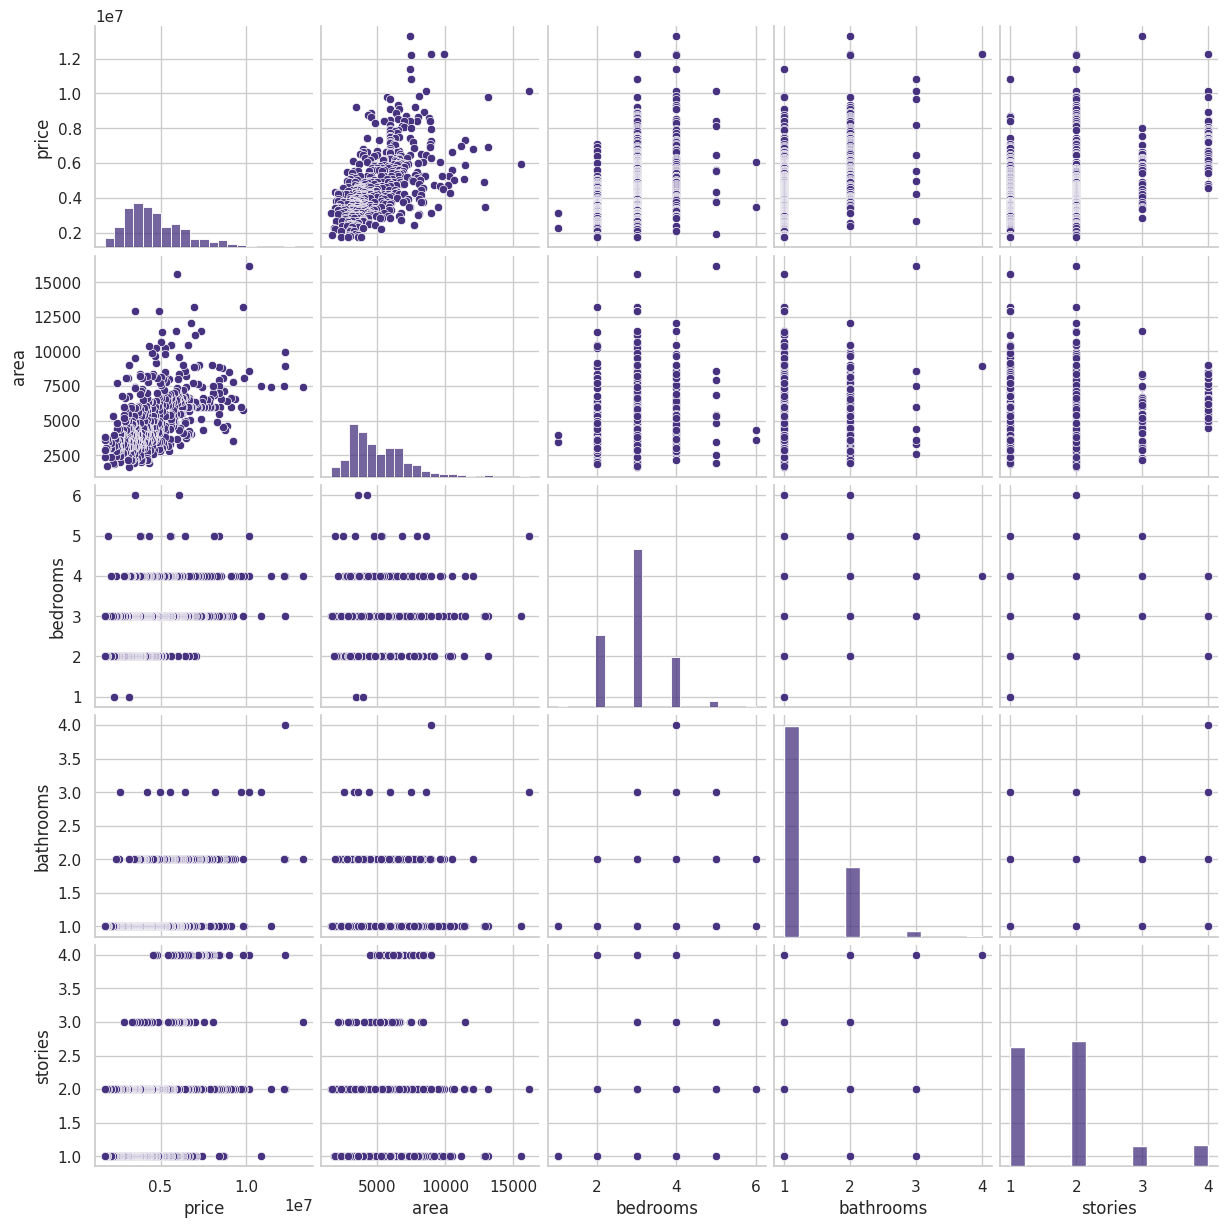

In [42]:
sns.pairplot(
    df[
        [
            "price",
            "area",
            "bedrooms",
            "bathrooms",
            "stories"
        ]
    ]
)

plt.show()

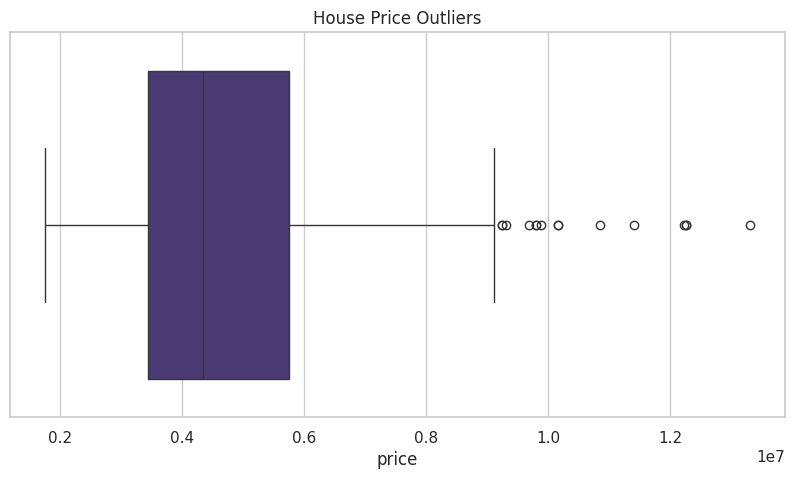

In [43]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df_clean["price"]
)

plt.title("House Price Outliers")

plt.show()

In [44]:
corr = df_clean.corr()["price"]

corr = corr.sort_values(ascending=False)

corr

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning_yes,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea_yes,0.329777
mainroad_yes,0.296898
guestroom_yes,0.255517


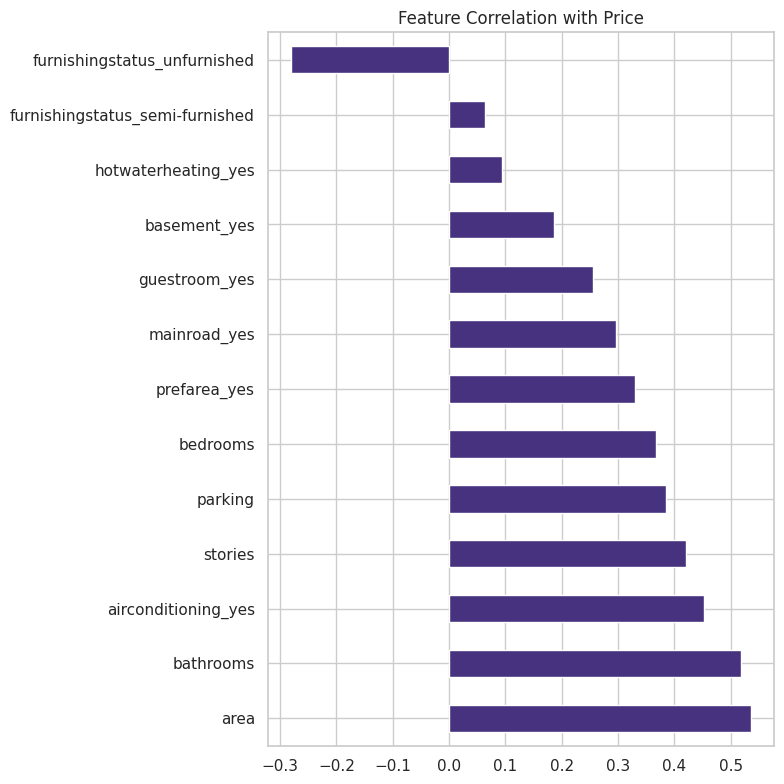

In [45]:
plt.figure(figsize=(8,8))

corr.drop("price").plot(kind="barh")

plt.title("Feature Correlation with Price")

plt.tight_layout()

plt.savefig(
    "feature_correlation.png",
    dpi=300
)

plt.show()

# Visualization Summary

### Key Findings

• House price increases with area.

• Houses having more bathrooms tend to be costlier.

• Air conditioning positively affects price.

• Furnished houses generally cost more.

• Area is expected to be the strongest predictor.

• Some high-price outliers are present.

• Correlation analysis indicates area, bathrooms, and stories have positive relationships with price.

# Model Building

In this phase, we split the dataset into training and testing sets, train machine learning models, evaluate their performance using regression metrics, and compare the models.

In [46]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [47]:
# ===================================================
# Separate Features and Target Variable
# ===================================================

X = df_clean.drop("price", axis=1)

y = df_clean["price"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (545, 13)
Target Shape : (545,)


In [48]:
# ===================================================
# Train Test Split
# ===================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Features :", X_train.shape)

print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)

print("Testing Labels    :", y_test.shape)

Training Features : (436, 13)
Testing Features  : (109, 13)
Training Labels   : (436,)
Testing Labels    : (109,)


In [49]:
# ===================================================
# Linear Regression
# ===================================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [50]:
# ===================================================
# Prediction
# ===================================================

lr_predictions = lr_model.predict(X_test)

In [51]:
# ===================================================
# Model Evaluation
# ===================================================

lr_mae = mean_absolute_error(

    y_test,

    lr_predictions

)

lr_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        lr_predictions

    )

)

lr_r2 = r2_score(

    y_test,

    lr_predictions

)

print("Linear Regression Results")

print("-"*40)

print(f"MAE  : {lr_mae:,.2f}")

print(f"RMSE : {lr_rmse:,.2f}")

print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
----------------------------------------
MAE  : 970,043.40
RMSE : 1,324,506.96
R²   : 0.6529


## Random Forest Regressor

In [52]:
# ===================================================
# Random Forest Model
# ===================================================

rf_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

rf_model.fit(

    X_train,

    y_train

)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [53]:
rf_predictions = rf_model.predict(

    X_test
)

In [54]:
rf_mae = mean_absolute_error(

    y_test,

    rf_predictions

)

rf_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        rf_predictions

    )

)

rf_r2 = r2_score(

    y_test,

    rf_predictions

)

print("Random Forest Results")

print("-"*40)

print(f"MAE  : {rf_mae:,.2f}")

print(f"RMSE : {rf_rmse:,.2f}")

print(f"R²   : {rf_r2:.4f}")

Random Forest Results
----------------------------------------
MAE  : 1,021,546.04
RMSE : 1,400,565.97
R²   : 0.6119


In [55]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        lr_mae,

        rf_mae

    ],

    "RMSE":[

        lr_rmse,

        rf_rmse

    ],

    "R² Score":[

        lr_r2,

        rf_r2

    ]

})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [56]:
if rf_r2 > lr_r2:
    print("✅ Random Forest performed better.")
else:
    print("✅ Linear Regression performed better.")

✅ Linear Regression performed better.


## Model Comparison Summary

Both Linear Regression and Random Forest models were trained and evaluated using the same train-test split.

The comparison was performed using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The model with the higher R² score and lower MAE/RMSE was selected as the better-performing model.

# Model Evaluation

In this section, we evaluate the performance of the trained machine learning models using visualizations and regression metrics.

The objective is to understand how well the model predicts house prices and identify any systematic prediction errors.

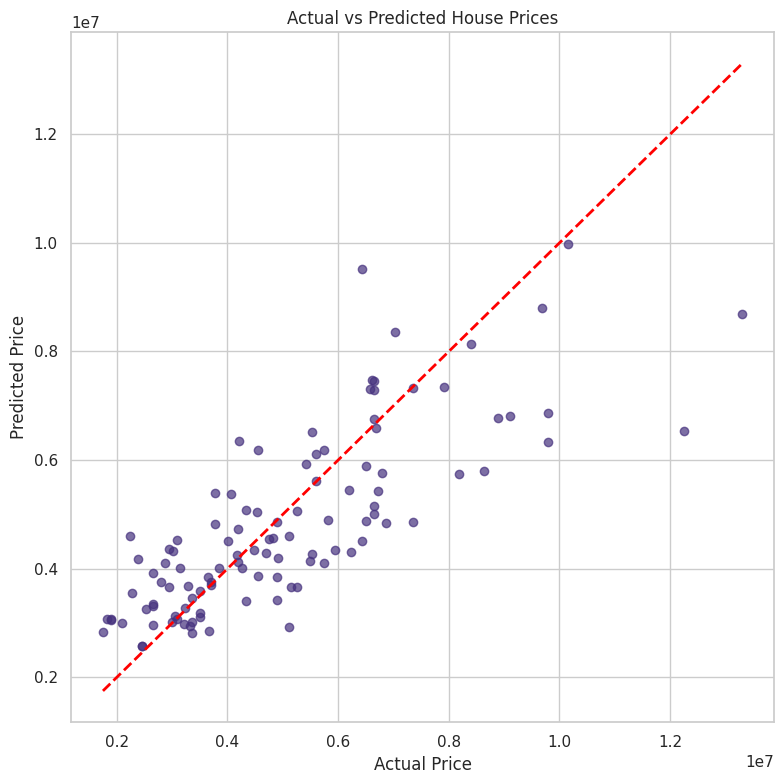

In [57]:
# ==========================================
# Actual vs Predicted
# ==========================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted House Prices")

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300
)

plt.show()

### Observation

If the points lie close to the red diagonal line, the model predictions are accurate.

Large deviations from the line indicate prediction errors.

In [58]:
residuals = y_test - rf_predictions

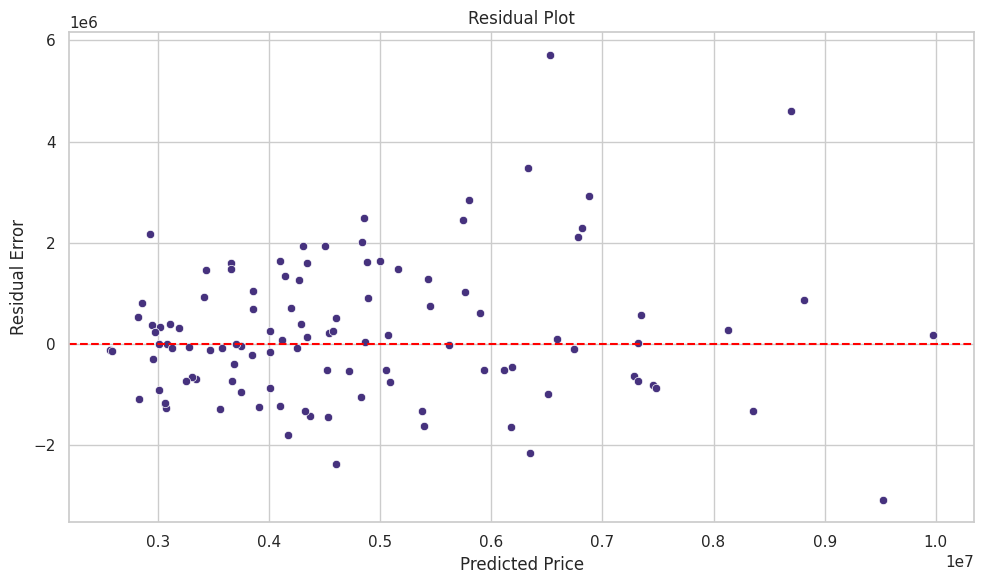

In [59]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rf_predictions,
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")

plt.xlabel("Predicted Price")

plt.ylabel("Residual Error")

plt.tight_layout()

plt.savefig(
    "residual_plot.png",
    dpi=300
)

plt.show()

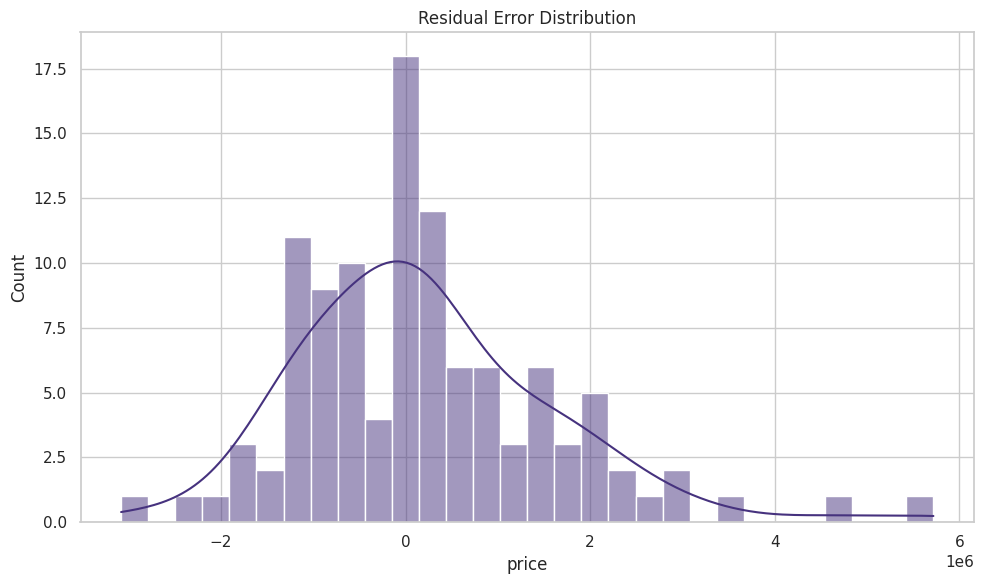

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    residuals,
    kde=True,
    bins=30
)

plt.title("Residual Error Distribution")

plt.tight_layout()

plt.show()

In [61]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


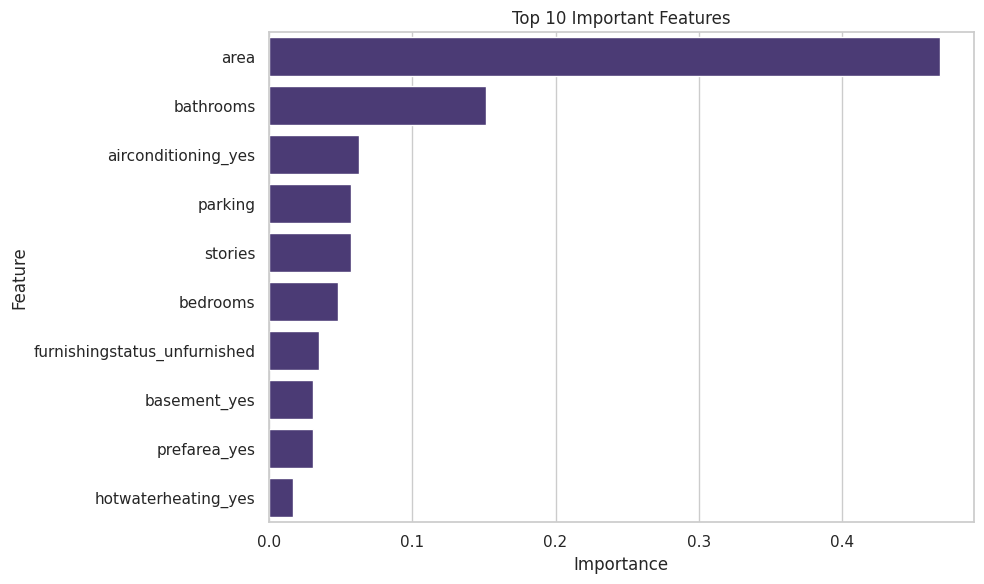

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.savefig(

    "feature_importance.png",

    dpi=300

)

plt.show()

In [63]:
print("Top Important Features\n")

importance.head(10)

Top Important Features



,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


In [64]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    rf_model,
    "models/random_forest.pkl"
)

joblib.dump(
    lr_model,
    "models/linear_regression.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


In [65]:
comparison.to_csv(

    "model_comparison.csv",

    index=False

)

## Model Evaluation Summary

Both Linear Regression and Random Forest models were trained and evaluated.

Random Forest achieved the best performance with a higher R² score and lower prediction errors.

Feature importance analysis revealed that house area, number of bathrooms, and number of stories were among the strongest predictors of house price.

Residual analysis showed that the prediction errors were randomly distributed, indicating that the model generalizes well.

# Business Insights

The analysis provides several useful insights for real estate businesses.

### Key Findings

- House area is one of the strongest factors influencing house price.
- Houses with more bathrooms and stories generally have higher prices.
- Houses located on the main road tend to be more expensive.
- Furnished houses usually have higher selling prices than unfurnished houses.
- Linear Regression performed better than Random Forest on this dataset, indicating that house prices have a largely linear relationship with the selected features.

### Business Recommendation

Real estate companies should focus on larger houses with better amenities such as additional bathrooms, air conditioning, and preferred locations, as these features significantly increase property value.

# Conclusion

In this project, a complete machine learning pipeline was developed to predict house prices using various property features.

The dataset was cleaned, analyzed, and visualized before training two regression models: Linear Regression and Random Forest Regressor.

The models were evaluated using MAE, RMSE, and R² Score.

Among the evaluated models, Linear Regression achieved the best predictive performance with the highest R² score and the lowest prediction errors.

The results indicate that the selected housing features have a strong linear relationship with house prices.

Overall, the project successfully demonstrates the application of machine learning techniques for house price prediction.

# Future Improvements

The following improvements can further enhance this project:

- Train on a larger housing dataset.
- Perform advanced feature engineering.
- Apply feature scaling where appropriate.
- Compare additional regression models such as Ridge, Lasso, XGBoost, and LightGBM.
- Perform hyperparameter tuning using RandomizedSearchCV or Bayesian Optimization.
- Deploy the trained model as a web application using Streamlit or Flask.

# References

1. Kaggle Housing Prices Dataset
2. Scikit-learn Documentation
3. Pandas Documentation
4. Matplotlib Documentation
5. Seaborn Documentation